In [ ]:
import pandas as pd

In [ ]:
X = 100_000
df = pd.read_csv('data/jackal_data.csv', nrows=X)
df.head()

In [4]:
df.memory_usage(deep=True).sum() / 1024**2 # MB

np.float64(75.81723403930664)

In [8]:
df.columns

Index(['Unnamed: 0', 'TAG', 'TIME', 'X', 'Y', 'Z', 'lat', 'lon', 'VARX',
       'VARY', 'COVXY', 'NBS', 'PENALTY', 'dateTime', 'DAY', 'Outliers',
       'Speed_m_s', 'STD', 'geometry', 'date', 'month', 'Season',
       'biological_season', 'Jackal_Name', 'Tag', 'dateTime_local', 'sunset',
       'Night', 'estimated_age', 'Sex'],
      dtype='object')

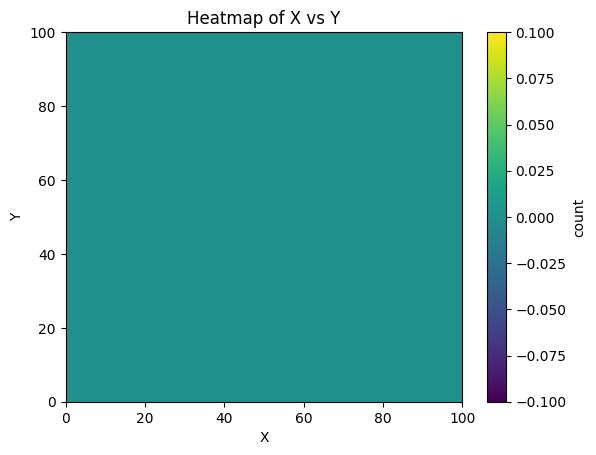

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

chunksize = 100_000
xbins = 100
ybins = 100

# Define bin ranges (adjust to your data)
x_min, x_max = 0, 100
y_min, y_max = 0, 100

heatmap = np.zeros((xbins, ybins))

for chunk in pd.read_csv(
    "jackal_data.csv",
    usecols=["X", "Y"],
    chunksize=chunksize
):
    h, _, _ = np.histogram2d(
        chunk["X"],
        chunk["Y"],
        bins=[xbins, ybins],
        range=[[x_min, x_max], [y_min, y_max]]
    )
    heatmap += h

plt.figure()
plt.imshow(
    heatmap.T,
    origin="lower",
    aspect="auto",
    extent=[x_min, x_max, y_min, y_max]
)
plt.colorbar(label="count")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Heatmap of X vs Y")
plt.show()
